In [4]:
import pandas as pd
import pickle

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression

from sklearn.linear_model import Lasso

from sklearn.metrics import root_mean_squared_error

In [5]:
import mlflow

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("h1_answers")


<Experiment: artifact_location='mlflow-artifacts:/890617403995446078', creation_time=1749559889708, experiment_id='890617403995446078', last_update_time=1749559889708, lifecycle_stage='active', name='h1_answers', tags={}>

Q1. Downloading the data

In [6]:
df = pd.read_parquet('./data/yellow_tripdata_2023-01.parquet')
print(len(df.columns))

19


Q2. Computing duration

In [7]:
df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)
df['duration'].std()


np.float64(42.59435124195458)

Q3. Dropping outliers

In [8]:
n_total = len(df)
df_filtered = df[(df['duration'] >= 1) & (df['duration'] <= 60)]
n_filtered = len(df_filtered)
fraction = n_filtered / n_total
print(f"Fraction of records left: {fraction:.3f}")

Fraction of records left: 0.981


Q4. One-hot encoding

In [9]:
df_filtered['PULocationID'] = df['PULocationID'].astype(str)
df_filtered['DOLocationID'] = df['DOLocationID'].astype(str)

dicts = df_filtered[['PULocationID', 'DOLocationID']].to_dict(orient='records')

dv = DictVectorizer(sparse=True)

X_train = dv.fit_transform(dicts)

y_train = df_filtered['duration'].values

print(f"Number of features (columns): {X_train.shape[1]}")


/var/folders/7t/76f41nd97kx9r0c9tp_szvgh0000gp/T/ipykernel_16188/2600130288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['PULocationID'] = df['PULocationID'].astype(str)
/var/folders/7t/76f41nd97kx9r0c9tp_szvgh0000gp/T/ipykernel_16188/2600130288.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['DOLocationID'] = df['DOLocationID'].astype(str)


Number of features (columns): 515


Q5. Training a model

In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

7.6492622258678935

Q6. Evaluating the model

In [11]:
df_val = pd.read_parquet('./data/yellow_tripdata_2023-02.parquet')


df_val['duration'] = df_val.tpep_dropoff_datetime - df_val.tpep_pickup_datetime
df_val.duration = df_val.duration.apply(lambda td: td.total_seconds() / 60)

df_val = df_val[(df_val['duration'] >= 1) & (df_val['duration'] <= 60)]

df_val['PULocationID'] = df_val['PULocationID'].astype(str)
df_val['DOLocationID'] = df_val['DOLocationID'].astype(str)

val_dicts = df_val[['PULocationID', 'DOLocationID']].to_dict(orient='records')
X_val = dv.transform(val_dicts)  # Don't re-fit!

In [12]:
y_val = df_val['duration'].values

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.811813648526847

Save the model

In [14]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv,lr), f_out)

Lasso model

In [15]:
with mlflow.start_run():

    mlflow.set_tag("developer", "ana")

    mlflow.log_param("train-data-path", "yellow_tripdata_2023-01.parquet")
    mlflow.log_param("valid-data-path", "yellow_tripdata_2023-02.parquet")

    alpha = 0.01

    mlflow.log_param("alpha", alpha)

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("rmse", rmse)

# One way to save the model in MLflow as artifact, but not the best one. See below. 
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

🏃 View run hilarious-wasp-196 at: http://127.0.0.1:5000/#/experiments/890617403995446078/runs/5f82e010cc204280842c0f32186ba7c1
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/890617403995446078


In [2]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/anastasijatrizna/Desktop/mlops-zoomcamp/mlops.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <98D50080-9632-3EA4-B874-146E55453763> /Users/anastasijatrizna/Desktop/mlops-zoomcamp/mlops.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Prebo

In [25]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

/usr/local/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [11:14:57] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:8.64256                          
[1]	validation-rmse:7.56969                          
[2]	validation-rmse:7.17851                          
[3]	validation-rmse:6.93399                          
[4]	validation-rmse:6.45037                          
[5]	validation-rmse:6.36587                          
[6]	validation-rmse:6.29946                          
[7]	validation-rmse:6.24033                          
[8]	validation-rmse:6.20024                          
[9]	validation-rmse:6.10842                          
[10]	validation-rmse:5.90227                         
[11]	validation-rmse:5.87774                         
[12]	validation-rmse:5.84642                         
[13]	validation-rmse:5.73238                         
[14]	validation-rmse:5.72123                         
[15]	validation-rmse:5.69458                         
[16]	validation-rmse:5.68222                         
[17]	validation-rmse:5.67649                         
[18]	validation-rmse:5.57924

From above run, check mlflow and select the best model. See the parameters and then train model based on the results one more time. Save it and log.

In [13]:
with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.204,
        'max_depth': 17,
        'min_child_weight': 1.24,
        'objective': 'reg:linear',
        'reg_alpha': 0.285,
        'reg_lambda': 0.004,
        'seed': 42
    }

    mlflow.xgboost.autolog() # see https://mlflow.org/docs/latest/tracking/autolog which models support autolog

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )


2025/05/27 11:37:57 WARNING mlflow.utils.autologging_utils: MLflow xgboost autologging is known to be compatible with 1.4.2 <= xgboost <= 3.0.0, but the installed version is 3.0.2. If you encounter errors during autologging, try upgrading / downgrading xgboost to a compatible version, or try upgrading MLflow.
/usr/local/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [11:38:18] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:9.32947
[1]	validation-rmse:8.82754
[2]	validation-rmse:8.47495
[3]	validation-rmse:8.21369
[4]	validation-rmse:8.03481
[5]	validation-rmse:7.91184
[6]	validation-rmse:7.82329
[7]	validation-rmse:7.67437
[8]	validation-rmse:7.61884
[9]	validation-rmse:7.56722
[10]	validation-rmse:7.52978
[11]	validation-rmse:7.41118
[12]	validation-rmse:7.38515
[13]	validation-rmse:7.35560
[14]	validation-rmse:7.30854
[15]	validation-rmse:7.29145
[16]	validation-rmse:7.20849
[17]	validation-rmse:7.19220
[18]	validation-rmse:7.15263
[19]	validation-rmse:7.13056
[20]	validation-rmse:7.11269
[21]	validation-rmse:7.09324
[22]	validation-rmse:7.08375
[23]	validation-rmse:7.05544
[24]	validation-rmse:7.04591
[25]	validation-rmse:7.03207
[26]	validation-rmse:7.01373
[27]	validation-rmse:7.00309
[28]	validation-rmse:6.98941
[29]	validation-rmse:6.98159
[30]	validation-rmse:6.91760
[31]	validation-rmse:6.90833
[32]	validation-rmse:6.89846
[33]	validation-rmse:6.88927
[34]	validation-rmse:6.8

2025/05/27 11:41:49 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2025/05/27 11:41:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.11/site-packages/mlflow/xgboost/__init__.py:168: UserWarning: [11:41:49] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2025/05/27 11:41:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run efficient-ant-170 at: http://127.0.0.1:5000/#/experiments/100578109370690606/runs/39412989bd404600bb58d9b425a68aee
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/100578109370690606


In [15]:
with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }

    mlflow.log_params(best_params)
    
    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

#Better way to save the model in mlflow. Note that autologin also saves the model!

#To disable autologin pass 

#    mlflow.xgboost.autolog(disable=True)


# Below will log the model information and file location. if you want to save it as artifact in mlflow
# you will need to save it locally and pass as artifact 

#    with open("models/preprocessor.b", "wb") as f_out:
#        pickle.dump(dv, f_out)
#    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow") #BETTER

/usr/local/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [10:56:05] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:9.66700
[1]	validation-rmse:9.32544
[2]	validation-rmse:9.02772
[3]	validation-rmse:8.77833
[4]	validation-rmse:8.52259
[5]	validation-rmse:8.33312
[6]	validation-rmse:8.17951
[7]	validation-rmse:8.00152
[8]	validation-rmse:7.89076
[9]	validation-rmse:7.79476
[10]	validation-rmse:7.71204
[11]	validation-rmse:7.64024
[12]	validation-rmse:7.57481
[13]	validation-rmse:7.52044
[14]	validation-rmse:7.46677
[15]	validation-rmse:7.35188
[16]	validation-rmse:7.31632
[17]	validation-rmse:7.28409
[18]	validation-rmse:7.25377
[19]	validation-rmse:7.15253
[20]	validation-rmse:7.12958
[21]	validation-rmse:7.10918
[22]	validation-rmse:7.02467
[23]	validation-rmse:7.00793
[24]	validation-rmse:6.98921
[25]	validation-rmse:6.97384
[26]	validation-rmse:6.95163
[27]	validation-rmse:6.93886
[28]	validation-rmse:6.84799
[29]	validation-rmse:6.83748
[30]	validation-rmse:6.76422
[31]	validation-rmse:6.75510
[32]	validation-rmse:6.74551
[33]	validation-rmse:6.73503
[34]	validation-rmse:6.6

2025/05/28 11:02:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/lib/python3.11/site-packages/mlflow/xgboost/__init__.py:168: UserWarning: [11:02:41] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
/usr/local/lib/python3.11/site-packages/mlflow/xgboost/__init__.py:168: UserWarning: [11:16:18] WARNING: /Users/runner/work/xgboost/xgboost/src/c_api/c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  xgb_model.save_model(model_data_path)
2025/05/28 11:16:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run glamorous-crane-186 at: http://127.0.0.1:5000/#/experiments/100578109370690606/runs/a59f1fca5d2343bc8b803c3cfb1275b3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/100578109370690606


mlflow.X.log_model

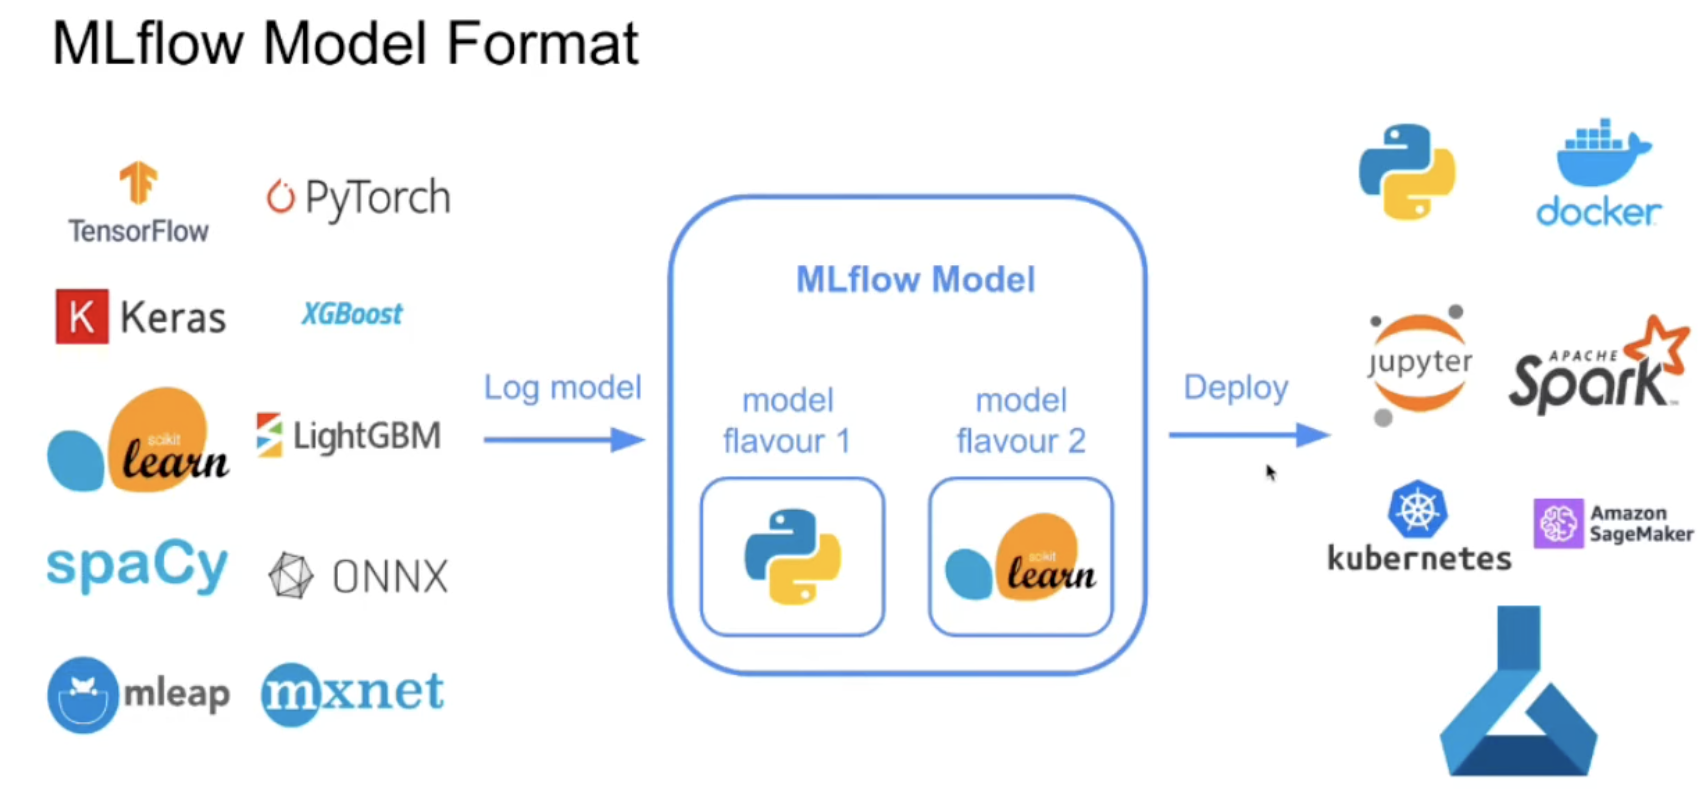